# Quick intro to py5

By [Allison Parrish](https://www.decontextualize.com/) for [Computational Letterforms and Layout](https://cll.decontextualize.com/).

If you like Python and like Processing/p5js, then py5 might be the right thing for you! Even if you only tolerate one or the other, you still might find it useful. Py5 is a version of [Processing](https://processing.org/) that you can program in Python. It's not a "port" of Processing in the strictest sense; in fact, thanks to the magic of [JPype](https://github.com/jpype-project/jpype/), it is actually making use of the actual Processing Java code under the hood, which you access through a series of wrapper functions and APIs. This combination means that you get all the speed and power of Processing (well, [most of the speed](https://py5coding.org/content/hybrid_programming.html)) while still retaining access to the Python programming language and its ecosystem.

Note that there are a few [quirks when running py5 on macOS](https://py5coding.org/content/macos_users.html) that you Apple lovers out there might want to be aware of.

# Installing py5

Installing py5 is a bit tricky because we need to install several components: the py5 library itself, the Java programming language's runtime, and the libraries that py5 relies on, including the library (JPype) that allows for communication between Python and py5. The [py5 documentation](https://py5coding.org/content/install.html) has extensive installation instructions, but I'm going to try to pick my way through it.

Install the py5 package with the cell below. This will download [my fork of py5](https://github.com/aparrish/py5) which (as of this writing) changes the installation configuration so that py5 will work with Python 3.13. (If installing from my fork gives you problems, then use the official installation instructions.)

In [ ]:
%pip install https://github.com/aparrish/py5/archive/refs/heads/main.zip

### Installing Java

Now try running the cell below:

In [1]:
!java -version

openjdk version "21.0.6" 2025-01-21
OpenJDK Runtime Environment (build 21.0.6+7-Ubuntu-124.04.1)
OpenJDK 64-Bit Server VM (build 21.0.6+7-Ubuntu-124.04.1, mixed mode, sharing)


If you get `command not found`, or the version is less than 17, you need to install Java, like it's 2002 or something. There's a PyPI package that makes it easy for you. Install the package like so:

In [ ]:
%pip install install-jdk

And then install Java with with that package:

In [2]:
import jdk
jdk.install('17')

'/home/allison/.jdk/jdk-17.0.15+6'

This will install a version of Java that is visible to Python, but isn't installed system-wide. If you no longer want Java on your system, just remove the folder with the name that was displayed after you installed it in the cell above.

### py5 and Jupyter Notebook

The official documentation encourages you to install one or both of py5's [custom Jupyter Notebook kernels](https://py5coding.org/content/install.html#id1). These allow you to use py5 in "imported mode" and "static mode" directly inside of your notebook (see [py5's five modes](https://py5coding.org/content/install.html#id1), which can be handy, especially for the purposes of quick prototyping or making tutorials). In this tutorial, however, I'm just going to [use the standard Python kernel](https://py5coding.org/tutorials/jupyter.html#using-the-standard-python-3-ipykernel-kernel), which requires us to write sketches in "[module mode](https://py5coding.org/content/py5_modes.html#module-mode)." The extra typing we have to do in py5 mode is a small price to pay for better compatibility with existing Python tools.

## py5 preliminaries

According to the documentation, we need to run the code in the following cell in order to ensure that py5 plays nice with Jupyter Notebook. (You'll need to run this cell every time you start the notebook!)

In [1]:
import sys
if sys.platform == 'darwin':
        get_ipython().run_line_magic('gui', 'osx')

Now we'll import the py5 library itself:

In [2]:
import py5_tools
import py5

... and load the `py5` Jupyter Notebook extension, which makes some "line magic" available to us that will be very handy:

In [3]:
%load_ext py5

# Drawing stuff with py5 in Jupyter Notebook

At its most basic, py5 is a library for drawing stuff. The library's drawing commands are the same commands that you use in [Processing](https://processing.org/), and similar to those used in [p5js](https://p5js.org) (which is itself designed to be similar to Processing). The main difference is py5's [naming conventions](https://py5coding.org/content/coming_from_processing_java.html#the-slightly-different-snake-case-names): in order to make py5 feel more "pythonic," it generally uses "snake case" names for functions and variables (e.g., names in which word boundaries are indicated with `_` and words are in all lower case, which `looks_like_this`), instead of the "camel case" convention used in Processing and p5js (which `looksLikeThis`). Check the [reference summary](https://py5coding.org/reference/summary.html) for a list of py5 functions corresponding to the most used Processing/p5js functions.

The `py5` Jupter Notebook extension (which we loaded in the previous section) makes it super easy to use py5 to render a single image inline in the Notebook. Here's an example:

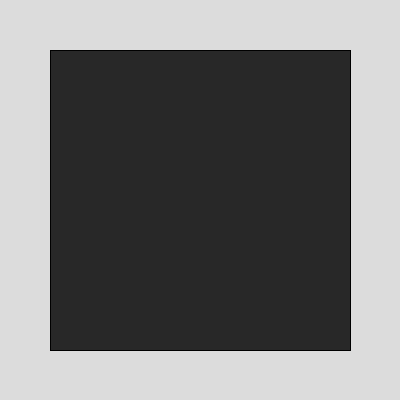

In [4]:
%%py5draw 400 400
py5.background(220)
py5.fill(40)
py5.rect(50, 50, 300, 300)

The `%%py5draw 400 400` line at the top of the cell tells py5 to create a canvas with the given dimensions (400 by 400), which we can then draw on with py5's drawing functions (`.background()`, `.fill()`, `.rect()`, etc.). If you're not familiar with Processing or p5js, you may want to [review the drawing functions available in py5](https://py5coding.org/reference/sketch.html) in the py5 documentation.

## Using values from elsewhere in the notebook

Note that we can use the `%%py5draw` line magic with code that references variables and functions defined elsewhere in the notebook. For example, here's some data:

In [5]:
import math
rect_size = 10
positions_x = [(i*25)+25 for i in range(20)]
positions_y = [100 + (math.cos(i/2)*50) for i in range(20)]

... and then a sketch that makes use of that data:

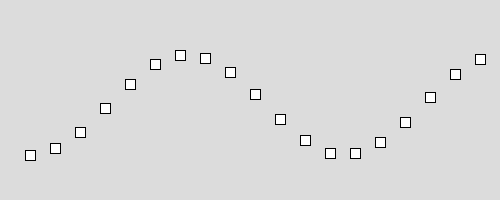

In [6]:
%%py5draw 500 200
py5.background(220)
for x, y in zip(positions_x, positions_y):
    py5.rect(x, y, rect_size, rect_size)

Note that, by default, you can *use* variables defined elsewhere in the notebook in a cell with `%%py5draw` magic, but you can't assign *new* values to those variables (or create new variables that will be visible outside of the cell). For example:

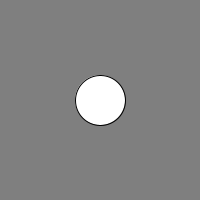

In [7]:
%%py5draw 200 200
py5.background(127)
py5.circle(100, 100, 50)
horse_status = "fine"
rect_size = 400

This cell executes without error, but the variable I defined inside of it does not appear to be accessible:

In [8]:
horse_status

NameError: name 'horse_status' is not defined

... and the value of the pre-existing variable is unchanged:

In [9]:
rect_size

10

If you're used to how variables work in Jupyter Notebook, then this behavior will seem a little surprising! But the official documentation [gives a pretty good justification](https://py5coding.org/tutorials/jupyter_notebook_magic_and_special_features.html#variable-scope) for the behavior. You *can* force py5 to use the Notebook's variable namespace instead of its own separate namespace using the `--unsafe` option in the line magic:

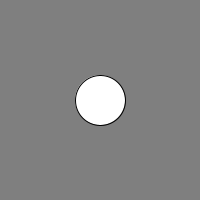

In [10]:
%%py5draw 200 200 --unsafe
py5.background(127)
py5.circle(100, 100, 50)
horse_status = "fine"
rect_size = 400

In [11]:
print(horse_status)
print(rect_size)

fine
400


Note that the namespace restriction only affects *creating* variables or *assigning new values* to variables. Even without the `--safe` parameter, you can still update lists and dictionaries that were first defined outside of the py5 cell. For example:

In [12]:
stuff = []
things = {}

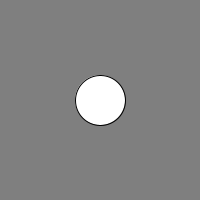

In [13]:
%%py5draw 200 200
py5.background(127)
py5.circle(100, 100, 50)
for i in range(10):
    stuff.append(i)
things['beep'] = 'boop'

In [14]:
print(stuff)
print(things)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
{'beep': 'boop'}


It's also fair game to call functions or methods on objects that you've defined elsewhere in the notebook.

## Image formats and saving files

By default, the `%%py5draw` magic renders to a raster image (a PNG, specifically), and automatically embeds that image in your Notebook. If you want to view the image on its own, or save it to a file, you can use shift+right click (or shift+ctrl+click) to bring up your browser's context menu and select the option to show the image in a new tab, or save the image to a file.

If you want vector graphics instead of a bitmap, you can also render to SVG using the `%%py5drawsvg` line magic instead:

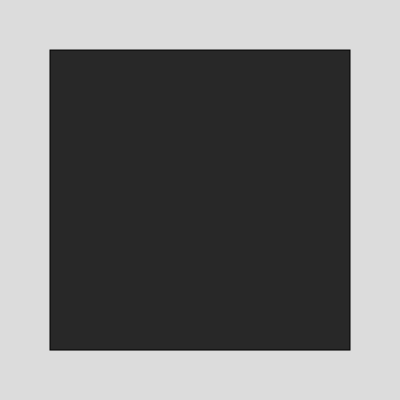

In [15]:
%%py5drawsvg 400 400
py5.background(220)
py5.fill(40)
py5.rect(50, 50, 300, 300)

You can save this image using the same browser context meny discussed above.

Both the `%%py5draw` and `%%py5drawsvg` magics also make it easy to generate the image and save it to a file in one fell swoop. If you add the `-f` option to the line magic and specify a filename afterwards, py5 will automatically save the output to disk under the filename that you specified. So you can get a PNG:

PNG file written to square.png


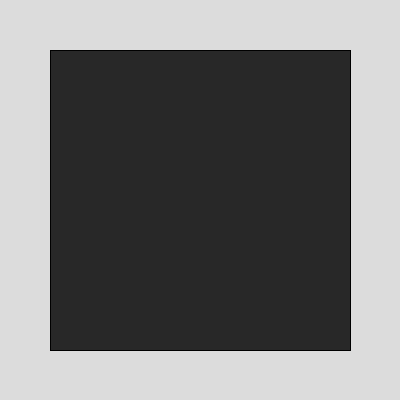

In [16]:
%%py5draw 400 400 -f square.png
py5.background(220)
py5.fill(40)
py5.rect(50, 50, 300, 300)

... or an SVG:

SVG drawing written to square.svg


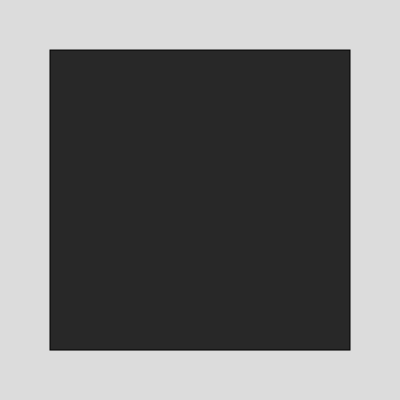

In [17]:
%%py5drawsvg 400 400 -f square.svg
py5.background(220)
py5.fill(40)
py5.rect(50, 50, 300, 300)

## Rendering frames with a bit more control

Another way to draw stuff with py5 in Jupyter Notebook is with the `py5.render_frame()` function. To use this function, you first define your own Python function that draws the thing you want to draw; you then pass that function as the first parameter to `py5.render_frame()`, along with `width` and `height` parameters to specify the width and height of the image that you want to draw. The `py5.render_frame()` function will then *call your function* with a single parameter: a `py5.Sketch` object. In your function, you can call all of the regular methods of the `py5.Sketch` object (i.e., the regular drawing commands you're used to using in py5/Processing/p5js). After your function returns, the `py5.render_frame()` function will evaluate to a Pillow `Image` object with the results of your drawing. Jupyter Notebook will then embed that image into your notebook:

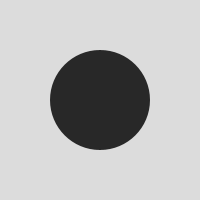

In [18]:
def draw_stuff(sketch):
    sketch.background(220)
    sketch.fill(40)
    sketch.no_stroke()
    sketch.circle(100, 100, 100)

py5.render_frame(draw_stuff, width=200, height=200)

This is a bit wordier than the `%%py5draw` technique, but I think it's a bit more flexible, since you can freely interleave code related to py5 and other code. Another benefit is that you can easily capture the returned image object and do your own stuff with it:

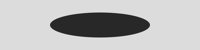

In [19]:
img = py5.render_frame(draw_stuff, width=200, height=200)
new_img = img.resize((200, 50)) # use Pillow to resize the image
new_img.save("testing.jpg") # save as a JPEG
new_img # show in notebook

To make things a bit easier when you're working with the `py5.render_frame` function, the official documentation [recommends using a type annotation](https://py5coding.org/tutorials/jupyter_render_helper_tools.html) when you're specifying parameters to your drawing function. The type annotation helps certain tools to produce more accurate autocompletion. (The Python `typing` module documentation has [a good overview of what type annotations are, and how they're useful](https://typing.python.org/en/latest/guides/libraries.html), and here's [a good cheat sheet for doing your own type annotations](https://mypy.readthedocs.io/en/stable/cheat_sheet_py3.html).) Here's the same example as above, with the annotation:

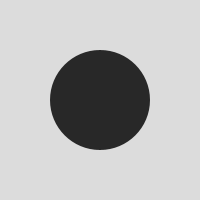

In [20]:
def draw_stuff(sketch: py5.Sketch):
    sketch.background(220)
    sketch.fill(40)
    sketch.no_stroke()
    sketch.circle(100, 100, 100)

py5.render_frame(draw_stuff, width=200, height=200)

This is functionally the same as the previous example, but you'll notice that if you hit the tab key after typing `sketch.`, you'll get a full list of methods belonging to the `py5.Sketch` object. Handy!

# Making animations with py5

The `py5.render_frame()` function has a cousin, `py5.render_frame_sequence()`, which works the same way, except it calls your function *multiple times*. Each time your function is called, the `py5.Sketch` object's `.frame_count` parameter is increased by one. Instead of evaluating to a Pillow `Image` object like `py5.render_frame()`, `py5.render_frame_sequence()` evaluates to a *list* of Pillow `Image` objects. This is a pretty good way to make an animation! Let's try it out.

In [21]:
frame_target = 12

def draw_frame(sketch: py5.Sketch):
    sketch.background(0)
    sketch.no_stroke()
    sketch.fill(255)
    sketch.rect_mode(sketch.CENTER)
    sketch.translate(100, 100)
    sketch.rotate(
        # .remap() is py5's equivalent of map() in Processing/p5js
        sketch.remap(sketch.frame_count, 0, frame_target, 0, sketch.PI/2)
    )
    sketch.rect(0, 0, 80, 80)

frames = py5.render_frame_sequence(draw_frame, width=200, height=200, limit=frame_target)
frames

[<PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>,
 <PIL.Image.Image image mode=RGB size=200x200>]

The `limit` parameter specifies the number of times that `py5.render_frame_sequence` should call your function.

Jupyter Notebook doesn't know how to embed a list of Pillow images as an animation, but we can peek at the images individually:

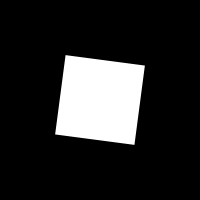

In [22]:
frames[0]

And then we can save the animation to a file using any of the multi-frame image formats that Pillow supports. For example, an animated GIF:

In [23]:
frames[0].save("animation.gif",
               append_images=frames[1:],
               duration=(1/30)*1000, # thirty frames per second
               loop=0 # loop forever
              )

The `duration` parameter specifies the length of time to wait between each frame (in milliseconds); the `loop` parameter specifies the number of times the animation should loop, with `0` meaning "loop forever."

If you open `animation.gif` in your browser, you should see a nice animated image. You may also prefer a higher fidelity format if you plan on creating higher fidelity animations, such as `WebP`:

In [24]:
frames[0].save("animation.webp",
               append_images=frames[1:],
               duration=(1/60)*1000, # sixty frames per second? sure
               loop=10 # loop ten times
              )

# Launching interactive sketches

We've seen a lot of cool stuff! But maybe the coolest thing you can do with py5 is *launch an interactive sketch* straight from your notebook. Unfortunately, the sketch itself isn't embedded in the notebook—it launches in a separate window—but being able to program and launch sketches in this way makes it easy to prototype, visualize, and play with whatever you're working on.

Here's how it works. You define a `setup()` function, and a `draw()` function, and any other of the `py5` callback functions (e.g., `mouse_pressed()`, `key_pressed()`) in a cell, and then you call `py5.run_sketch()`. The `py5.run_sketch()` function checks your notebook for functions with the corresponding names, and then launches a sketch using those functions. (Specifically, the `setup()` function will be called once, and then the `draw()` function will be called sixty times per second, over and over again, until you close the window.)

Here's an example:

In [25]:
def setup():
    py5.size(400, 400) # py5 uses `size()` to initialize the drawing surface, not `createCanvas()` as in p5js
def draw():
    py5.background(0)
    py5.fill(255)
    py5.circle(py5.mouse_x, py5.mouse_y, 50)
py5.run_sketch()

When you run the cell above, a window should pop up with a little interactive sketch (a white circle on a black background follows your mouse). Neat!

(If you want to be able to have multiple interactive sketches running at once, you may want to look into py5's "[class mode](https://py5coding.org/content/py5_modes.html#class-mode)," which lets you have separate objects for each sketch.)

## Getting data into sketches

One of the benefits of using Jupyter Notebook with py5 is that we can do Jupyter Notebook-ey stuff and then use the results of that in the interactive sketch. Just as an example, I'm going to use numpy below to generate an array of a few dozen random XY coordinates (in a two-dimensional array):

In [26]:
import numpy as np
circle_count = 100
coords = np.random.uniform(0, 400, size=(circle_count, 2))

... and then maybe some random colors (a three-dimensional array):

In [27]:
colors = np.random.uniform(0, 256, size=(circle_count, 3))

And now I can use that data in a sketch:

In [28]:
def setup():
    py5.size(400, 400)

def draw():
    py5.background(255)
    py5.no_stroke()
    for i in range(circle_count):
        x, y = coords[i][0], coords[i][1]
        # alpha increases with distance to mouse
        alpha = py5.remap(
            py5.dist(py5.mouse_x, py5.mouse_y, x, y), 0, 200, 255, 0
        )
        py5.fill(colors[i][0], colors[i][1], colors[i][2], alpha) 
        py5.circle(x, y, 50)

py5.run_sketch()

When you run the sketch, a window should pop up with a bunch of colorful circles whose transparency increases as their distance from the mouse increases.

## Gathering data from sketches

Making *changes* to variables from inside a sketch is a little bit more tricky. Let's start with a simple example: a circle that gets bigger every time you click.

In [29]:
click_count = 0

def setup():
    py5.size(200, 200)

def draw():
    py5.background(255)
    py5.no_fill()
    py5.stroke(0)
    py5.circle(100, 100, click_count*5)

def mouse_pressed():
    global click_count
    click_count += 1

py5.run_sketch()

What's that `global` word doing there? It has to do with Python's [variable scope rules](https://www.pythoncheatsheet.org/cheatsheet/functions#local-and-global-scope). Briefly, code inside of a function can *access* variables defined outside that function, but cannot *assign a new value* to a variable defined outside that function. If you want to be able to assign values to such a variable, (i.e., a global variable), you need to use the declaration `global` followed by the name of the variable somewhere inside the function (usually at the top). If you remove `global click_count` from this function, the attempt to overwrite the value of `click_count` (i.e., `click_count += 1`) will cause an error.

When you're writing sketches in this fashion, you *can* access variables declared inside the cell containing the sketch. For example, the cell below should show you how many times you clicked while the sketch was running:

In [30]:
click_count

11

You don't need to use `global` if you're just going to call methods on an object stored in a global variable, or if the global variable is a list or dictionary and you want to add/remove items from it. Let's do a quick example demonstrating this. In the cell below, I define an empty list:

In [31]:
click_coords = []

And then I'll write a quick sketch that adds a new `(x, y)` pair to the list whenever the user clicks:

In [32]:
def setup():
    py5.size(400, 400)

def draw():
    py5.background(255)
    py5.no_stroke()
    for coord in click_coords:
        py5.fill(0)
        py5.circle(coord[0], coord[1],
            # make the points pulse a little
            py5.remap(np.sin(coord[0]+coord[1]+py5.frame_count*0.05), -1, 1, 5, 25)
        )

def mouse_pressed():
    click_coords.append((py5.mouse_x, py5.mouse_y))

py5.run_sketch()

After you run this sketch, you'll notice that the `click_coords` list has the locations that you just clicked:

In [33]:
click_coords

[(47, 38),
 (107, 214),
 (237, 116),
 (160, 68),
 (228, 234),
 (142, 328),
 (361, 321),
 (351, 44),
 (33, 304)]

Additionally, if you run the sketch *again*, you'll notice that the sketch *starts* with the points that you'd clicked in the previous run! (If you want to reset the clicked points before each time you run the sketch, move the code that initializes the `click_coords` variable into the cell that contains your sketch.)

We could even use that data to draw another image with py5:

In [34]:
from bezmerizing import Polyline
pline = Polyline(click_coords)
shape = pline.fancy_curve([25, 10, 30, 10, 25], samples_per=12)

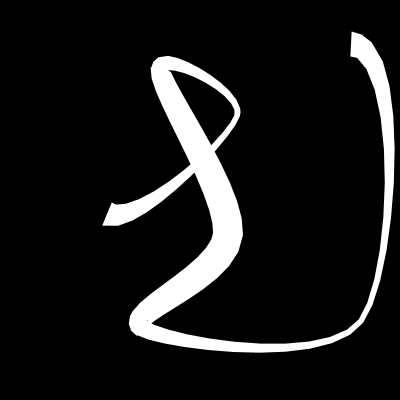

In [35]:
%%py5draw 400 400
py5.background(0)
py5.fill(255)
py5.no_stroke()
py5.begin_shape()
py5.vertices(shape.vertices)
py5.end_shape()

# A quick example: Grid glyph typewriter

Let's reuse the `grid_glyph()` function from the [Lines and Asemic Writing](https://github.com/aparrish/material-of-language/blob/master/lines-and-asemic-vsketch.ipynb) notebook:

In [36]:
from scipy.stats import truncnorm
def t_normal(a, b, mu, sigma):
    tn = truncnorm((a-mu)/sigma, (b-mu)/sigma, loc=mu, scale=sigma)
    return tn.rvs(1)[0]

def grid_glyph():
    pts = []
    for i in range(int(t_normal(4, 12, 8, 2))):
        x = (np.random.choice([-0.5, 0, 0.5]))
        y = (np.random.choice([-0.5, 0, 0.5]))
        pts.append([x, y])
    return pts

The following cell defines a simple py5 sketch that draws a glyph to the screen when a key is pressed. It keeps track of a virtual "cursor" position (i.e., the position where the current glyph should be drawn), and moves the cursor after each keypress, so that the next glyph will be drawn right next to the previous glyph. When the cursor moves too far to the right, it resets to the left side of the screen and moves down to the next line; when the cursor moves too far down the page, the canvas is erased and the cursors reset to their initial position. Perfect visual for your next low-budget scifi production.

Note that the `draw()` function is empty in this example. (In Python, the `pass` keyword indicates that a block of code should have no contents.) The reason for this is that all of the drawing is done in the `key_pressed()` callback, and there is no animation.

In [37]:
cursor_x = 0
cursor_y = 0
glyph_size = 20

def setup():
    py5.size(400, 400)
    py5.background(0)

    # glyph aesthetics
    py5.stroke(255, 255, 0)
    py5.no_fill()
    py5.stroke_cap(py5.ROUND)
    py5.stroke_join(py5.ROUND)

def draw():
    pass

def key_pressed():
    global cursor_x, cursor_y

    # generate a glyph
    new_glyph = grid_glyph()

    # draw the glyph at the current cursor position
    py5.push_matrix()
    py5.translate(cursor_x + glyph_size, cursor_y + glyph_size)
    # geometry returned from function is unit size, so scale it
    # up to the size we actually want
    py5.scale(glyph_size)
    # we need to scale down the stroke weight proportionally with
    # the scale
    py5.stroke_weight((1/glyph_size)*2.5)
    py5.begin_shape()
    py5.vertices(new_glyph)
    py5.end_shape()
    py5.pop_matrix()

    cursor_x += glyph_size * 1.25
    if cursor_x > py5.width - glyph_size*2:
        cursor_x = 0
        cursor_y += glyph_size * 1.25

    if cursor_y > py5.height - glyph_size*2:
        py5.background(0)
        cursor_x = 0
        cursor_y = 0

py5.run_sketch()

# A less quick example: Mouse gestures to asemic writing

In [38]:
squiggles = []
current_squig = None
last_add = 0

def setup():
    py5.size(400, 400)

def draw():
    py5.background(255)

    # draw completed squiggles
    py5.no_stroke()
    py5.fill(0)
    for item in squiggles:
        py5.begin_shape()
        py5.vertices(item.vertices)
        py5.end_shape()

    # draw the current input
    if current_squig is not None:
        py5.stroke(0)
        py5.stroke_weight(1)
        py5.no_fill()
        py5.begin_shape()
        py5.vertices(current_squig.vertices)
        py5.end_shape()

# reset on keypress
def key_pressed():
    global squiggles, current_squig
    squiggles = []
    current_squig = None

# start a new squiggle on mouse press
def mouse_pressed():
    global current_squig
    current_squig = Polyline([
        [float(py5.pmouse_x), float(py5.pmouse_y)],
        [float(py5.pmouse_x), float(py5.pmouse_y)],
        [float(py5.mouse_x), float(py5.mouse_y)]
    ])

# add another point to the squiggle
def mouse_dragged():
    global current_squig, last_add
    if current_squig is not None and py5.millis() > last_add + 20:
        current_squig += Polyline([[float(py5.mouse_x), float(py5.mouse_y)]])
        last_add = py5.millis()

# add currents squiggle to the list
def mouse_released():
    global current_squig
    if current_squig is not None:
        limit = np.random.uniform(10, 15)
        # add noise to the line
        current_squig.vertices += np.random.uniform(-limit, limit, size=current_squig.vertices.shape)
        # convert to a fancy curve
        squiggles.append(current_squig.augment().fancy_curve(
            # variation in thickness scaled to number of points
            [0] + ([3, 1] * (len(current_squig)//2)) + [0],
            samples_per=10,
            tightness=np.random.uniform(-3, 0)))
        current_squig = None
    
py5.run_sketch()